# EDA

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

_dataset_path="datasets/WA_Fn-UseC_-HR-Employee-Attrition.csv"

In [16]:
df=pd.read_csv(_dataset_path)

In [17]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [18]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [20]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [26]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


                          Attrition
Attrition                  1.000000
OverTime                   0.246118
MaritalStatus              0.162070
DistanceFromHome           0.077924
JobRole                    0.067151
Department                 0.063991
NumCompaniesWorked         0.043494
Gender                     0.029453
EducationField             0.026846
MonthlyRate                0.015170
PerformanceRating          0.002889
BusinessTravel             0.000074
HourlyRate                -0.006846
EmployeeNumber            -0.010577
PercentSalaryHike         -0.013478
Education                 -0.031373
YearsSinceLastPromotion   -0.033019
RelationshipSatisfaction  -0.045872
DailyRate                 -0.056652
TrainingTimesLastYear     -0.059478
WorkLifeBalance           -0.063939
EnvironmentSatisfaction   -0.103369
JobSatisfaction           -0.103481
JobInvolvement            -0.130016
YearsAtCompany            -0.134392
StockOptionLevel          -0.137145
YearsWithCurrManager      -0

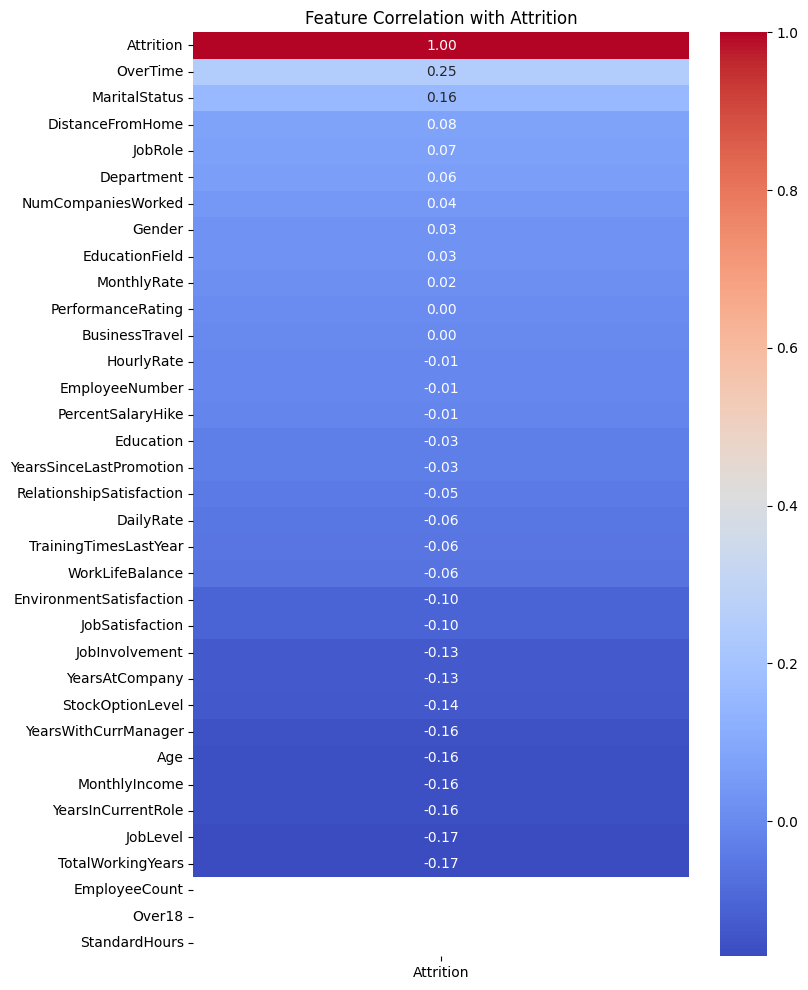

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv(_dataset_path)

# Copy dataset
data = df.copy()

# Encode categorical columns
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Compute correlation matrix
corr_matrix = data.corr()

# Correlation of all features with Attrition
attrition_corr = corr_matrix[['Attrition']].sort_values(
    by='Attrition',
    ascending=False
)

# Print correlations
print(attrition_corr)

# Plot heatmap
plt.figure(figsize=(8, 12))

sns.heatmap(
    attrition_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation with Attrition")
plt.show()

#### Exploratory Data Analysis Conclusions:
- dataset is imbalanced
- shows that the datset is clean
- no missing values
- need feature selection in preprocessing step
- need to label encode categorical values

# Preprocessor

In [22]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop('Attrition', axis=1)
y = data['Attrition']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                     Feature  Importance
17             MonthlyIncome    0.068485
0                        Age    0.057602
21                  OverTime    0.055375
27         TotalWorkingYears    0.050839
2                  DailyRate    0.050452
11                HourlyRate    0.048364
18               MonthlyRate    0.047666
8             EmployeeNumber    0.047490
4           DistanceFromHome    0.046551
30            YearsAtCompany    0.041176
19        NumCompaniesWorked    0.032272
22         PercentSalaryHike    0.032198
33      YearsWithCurrManager    0.029870
9    EnvironmentSatisfaction    0.029436
14                   JobRole    0.028555
26          StockOptionLevel    0.027814
32   YearsSinceLastPromotion    0.027420
15           JobSatisfaction    0.026850
29           WorkLifeBalance    0.026710
28     TrainingTimesLastYear    0.025909
12            JobInvolvement    0.025009
13                  JobLevel    0.023620
16             MaritalStatus    0.023314
31        YearsI

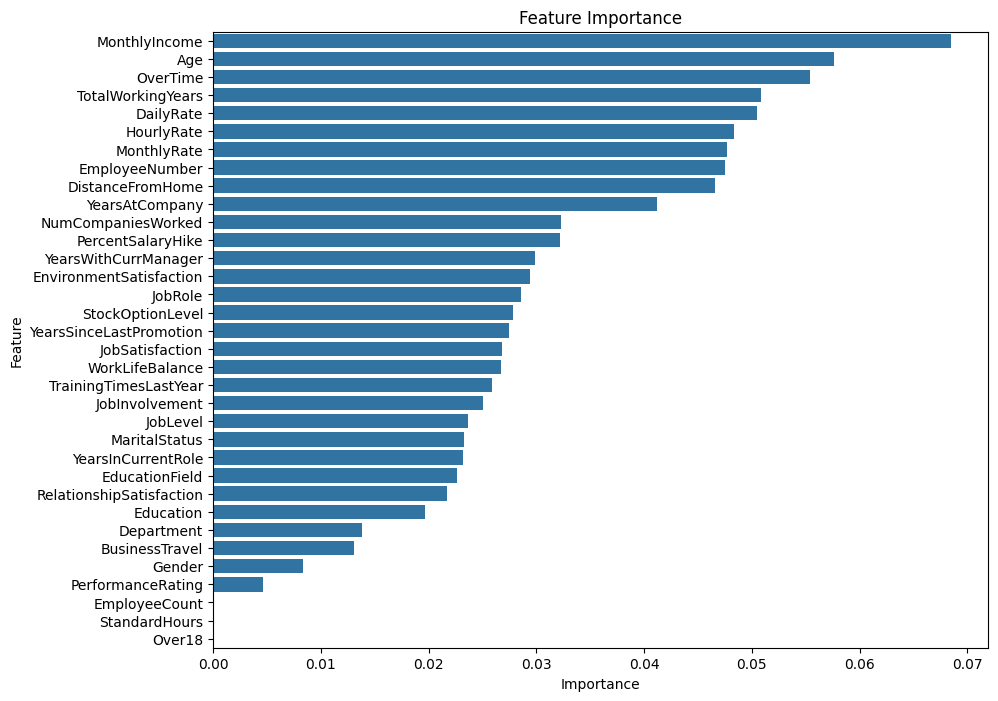

In [23]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

Selected Features:
 -   'Age',
 -   'MonthlyIncome',
 -   'OverTime',
 -   'DistanceFromHome',
 -   'JobSatisfaction',
 -   'EnvironmentSatisfaction',
 -   'WorkLifeBalance',
 -   'StockOptionLevel',
 -   'YearsAtCompany',
 -   'YearsSinceLastPromotion',
 -   'YearsWithCurrManager',
 -   'TotalWorkingYears',
 -   'NumCompaniesWorked',
 -   'JobInvolvement',
 -   'PercentSalaryHike'

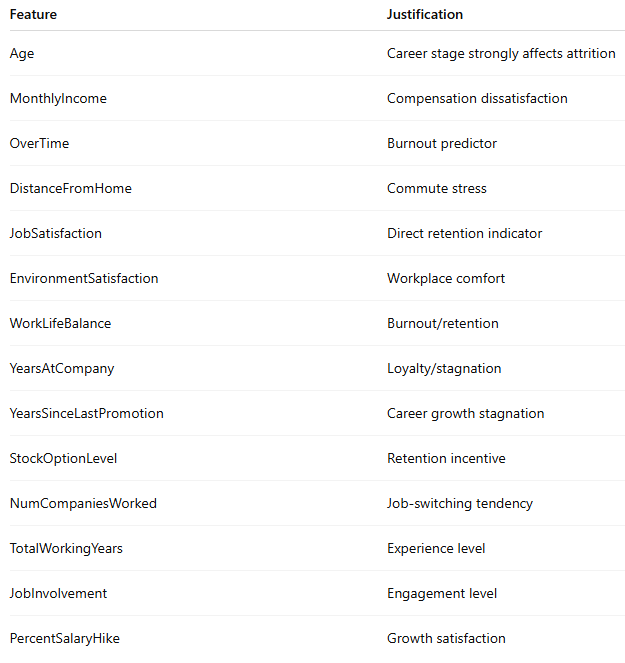

# Model Selection


MODEL: Logistic Regression

Accuracy  : 0.7245
Precision : 0.3365
Recall    : 0.7447
F1 Score  : 0.4636

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.72      0.81       247
           1       0.34      0.74      0.46        47

    accuracy                           0.72       294
   macro avg       0.64      0.73      0.64       294
weighted avg       0.84      0.72      0.76       294



g:\anaconda3\envs\NtwkAnomaly\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


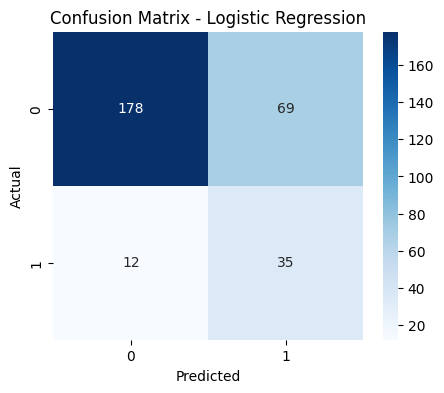


MODEL: Decision Tree

Accuracy  : 0.7755
Precision : 0.3208
Recall    : 0.3617
F1 Score  : 0.3400

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       247
           1       0.32      0.36      0.34        47

    accuracy                           0.78       294
   macro avg       0.60      0.61      0.60       294
weighted avg       0.79      0.78      0.78       294



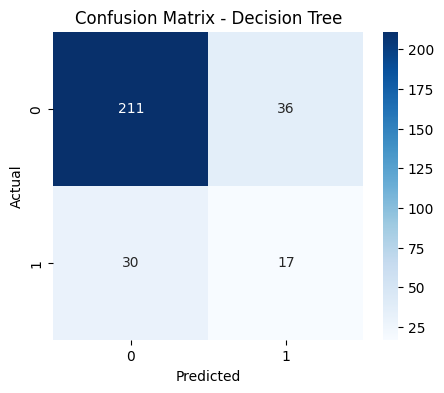


MODEL: Random Forest

Accuracy  : 0.8299
Precision : 0.4000
Recall    : 0.1277
F1 Score  : 0.1935

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.40      0.13      0.19        47

    accuracy                           0.83       294
   macro avg       0.63      0.55      0.55       294
weighted avg       0.78      0.83      0.79       294



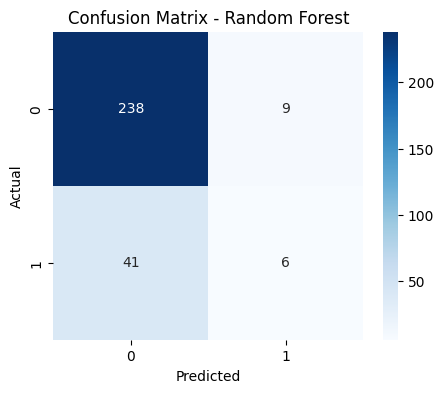


MODEL: AdaBoost

Accuracy  : 0.8469
Precision : 0.5385
Recall    : 0.2979
F1 Score  : 0.3836

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.54      0.30      0.38        47

    accuracy                           0.85       294
   macro avg       0.71      0.62      0.65       294
weighted avg       0.82      0.85      0.83       294



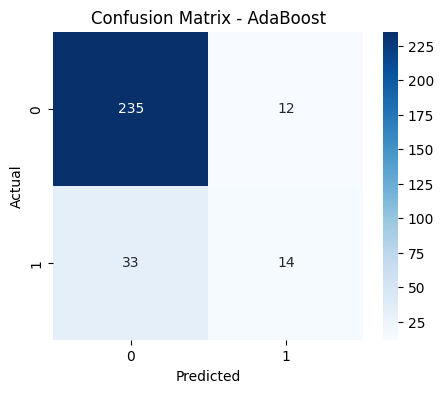


MODEL COMPARISON

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.724490   0.336538  0.744681  0.463576
1        Decision Tree  0.775510   0.320755  0.361702  0.340000
2        Random Forest  0.829932   0.400000  0.127660  0.193548
3             AdaBoost  0.846939   0.538462  0.297872  0.383562


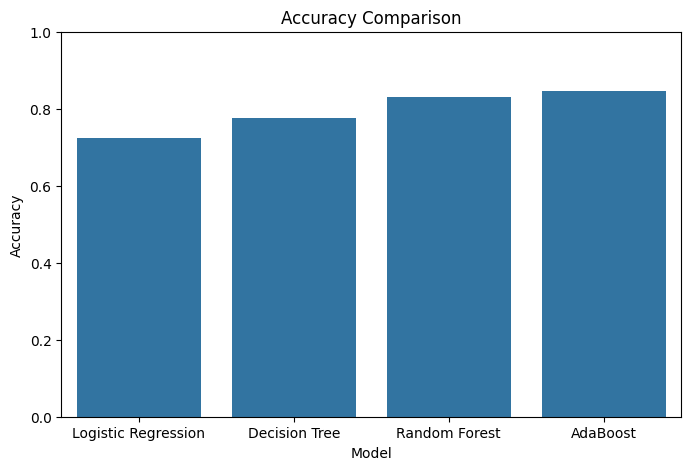

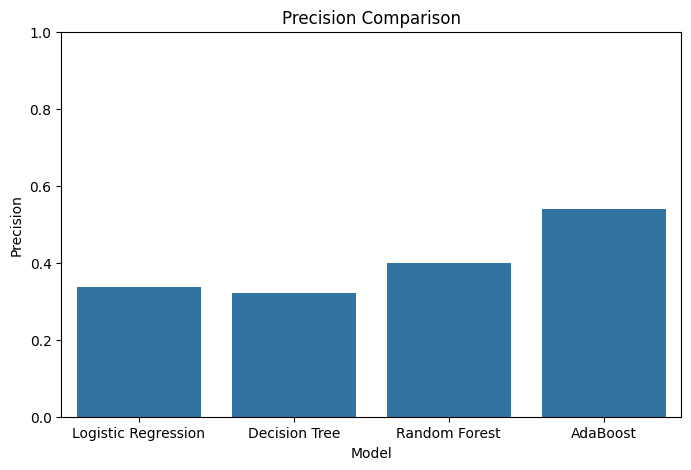

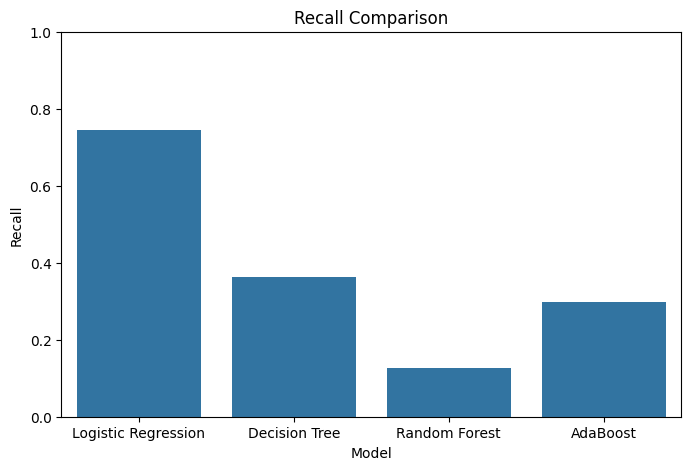

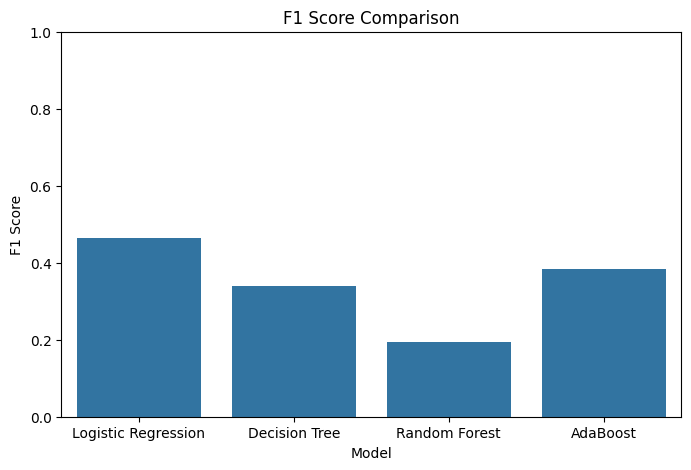

In [24]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

X_train = pd.read_csv("datasets/X_train.csv")
X_test = pd.read_csv("datasets/X_test.csv")

y_train = pd.read_csv("datasets/y_train.csv").values.ravel()
y_test = pd.read_csv("datasets/y_test.csv").values.ravel()



# INITIALIZE MODELS


models = {

    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    )
}

# TRAIN + EVALUATE MODELS
results = []

for name, model in models.items():

    print(f"="*30 +"\n")
    print(f"MODEL: {name}")
    print(f"="*30 +"\n")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    # Print metrics
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # COnfusion Matrix

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# Compare Models

results_df = pd.DataFrame(results)

print(f"="*30 +"\n")
print("MODEL COMPARISON")
print(f"="*30 +"\n")

print(results_df)

# Visualize Model Performance

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x='Model',
        y=metric,
        data=results_df
    )

    plt.title(f'{metric} Comparison')

    plt.ylim(0, 1)

    plt.show()




In [25]:
# Model Selection
# Usually for attrition:
# Recall + F1 are more important than Accuracy
#
# Because:
# Missing a leaving employee is costly.

best_model = results_df.sort_values(
    by='F1 Score',
    ascending=False
).iloc[0]

print(f"="*30 +"\n")
print("BEST MODEL")
print(f"="*30 +"\n")

print(best_model)




BEST MODEL

Model        Logistic Regression
Accuracy                 0.72449
Precision               0.336538
Recall                  0.744681
F1 Score                0.463576
Name: 0, dtype: object
